In [1]:
import pandas as pd
import matplotlib.pyplot as plt

In [ ]:
df = pd.read_csv("YOUR_PATH_HERE")

print(df.head())

print(df.shape)

print(df.info())

   match_id  team0_won  team0_team_total_kills  team0_team_total_deaths  \
0   1741000          1                      62                       46   
1  30579330          0                      61                       45   
2  38763513          1                      49                       51   
3  39388145          0                      45                       49   
4  39162555          0                      42                       42   

   team0_team_total_networth  team0_team_total_damage  \
0                     199365                   172895   
1                     208751                   178724   
2                     228325                   174032   
3                     195655                   181129   
4                     185832                   174299   

   team0_team_total_objectivedamage  team0_team_avg_level  \
0                             30021             23.500000   
1                             16059             30.500000   
2                      

# Inspecting Missing Values and Data/Features Distributions

In [3]:
missing = df.isnull().sum()

missing = missing[missing > 0]

print(missing)

Series([], dtype: int64)


In [4]:
print(df["team0_won"].value_counts())

print(df["team0_won"].value_counts(normalize=True))

team0_won
1    5719
0    5589
Name: count, dtype: int64
team0_won
1    0.505748
0    0.494252
Name: proportion, dtype: float64


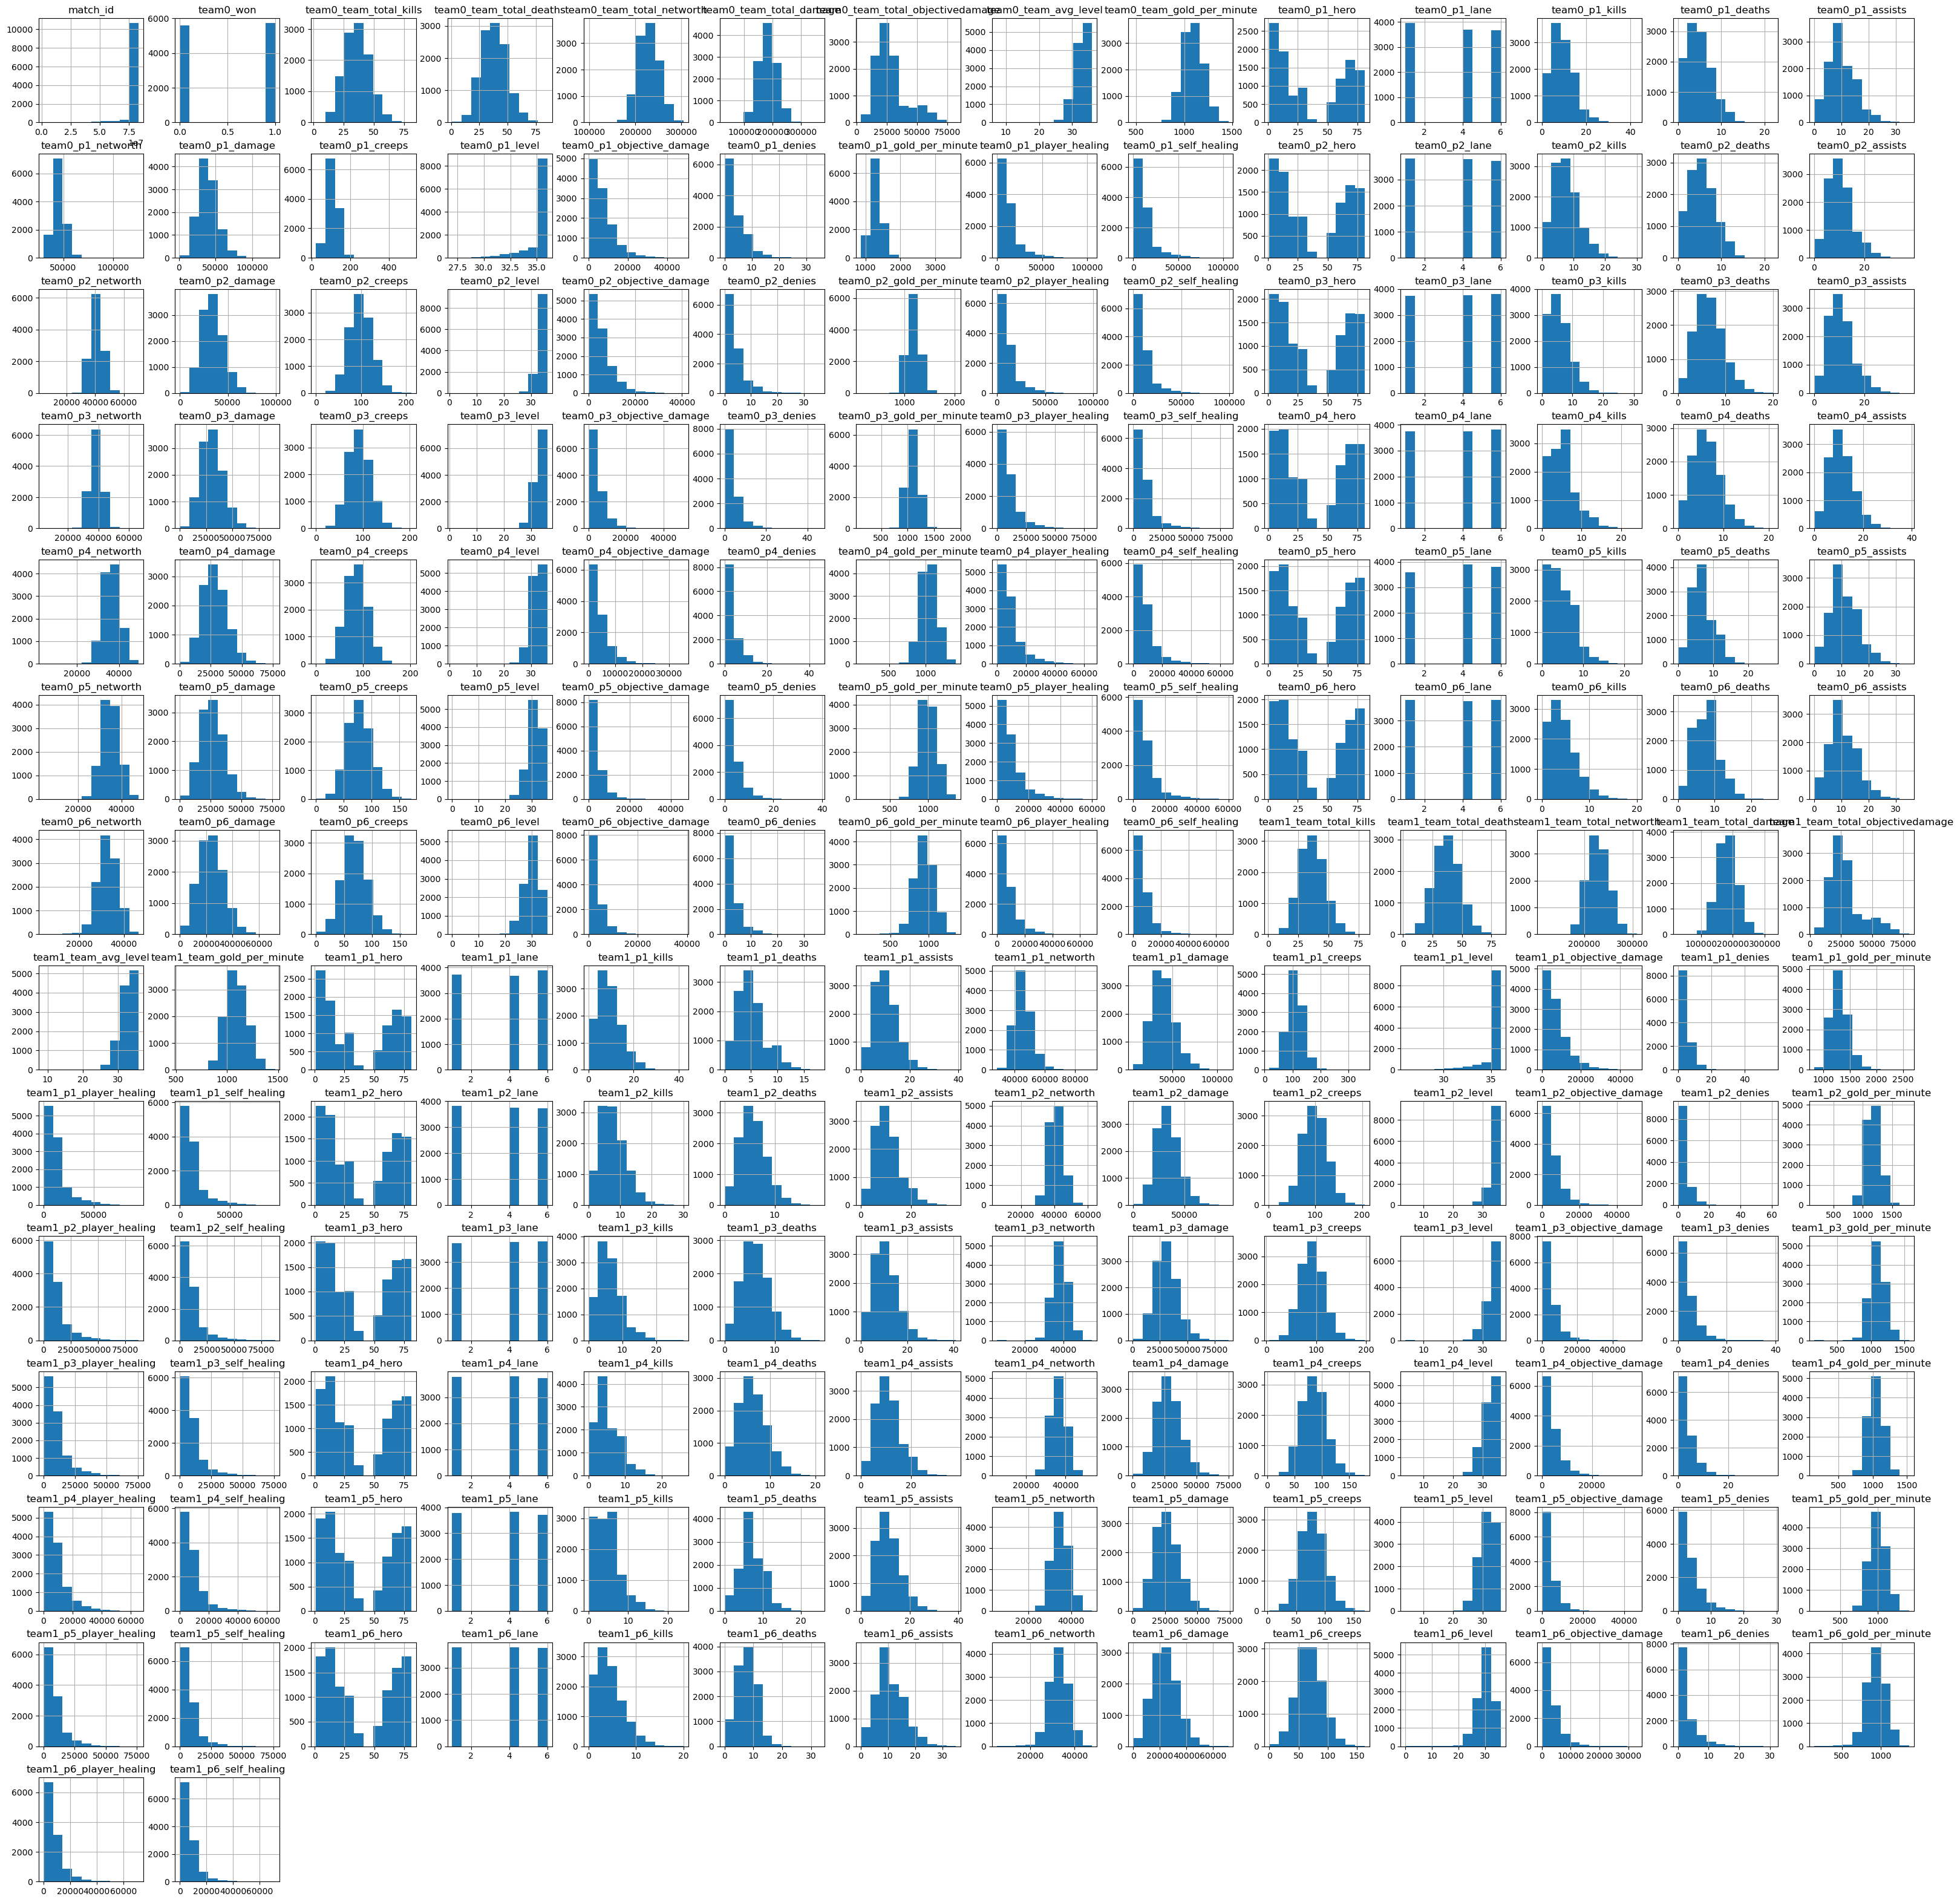

In [5]:
df.hist(figsize=(40, 40))

plt.show()

# Removing Outliers

count     11308.000000
mean     228857.582773
std       22186.660399
min       97901.000000
25%      212942.500000
50%      228227.500000
75%      244333.500000
max      304555.000000
Name: team0_team_total_networth, dtype: float64


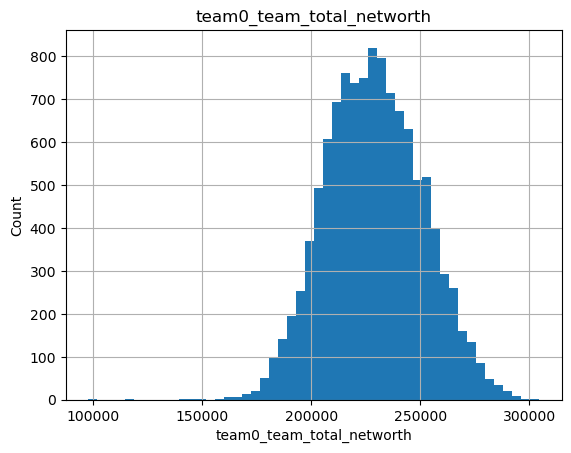

In [6]:
feature = "team0_team_total_networth"

print(df[feature].describe())

df[feature].hist(bins=50)

plt.title(feature)

plt.xlabel(feature)

plt.ylabel("Count")

plt.show()

In [7]:
threshold = 125000

count = (df["team0_team_total_networth"] < threshold).sum()

print(count)

outliers = df[df["team0_team_total_networth"] < 125000]

print((outliers.head(20)))

2
       match_id  team0_won  team0_team_total_kills  team0_team_total_deaths  \
2699   82180071          1                       4                        9   
10771  83239773          0                       8                        7   

       team0_team_total_networth  team0_team_total_damage  \
2699                      114748                    33494   
10771                      97901                    31103   

       team0_team_total_objectivedamage  team0_team_avg_level  \
2699                              21785                  15.0   
10771                             11039                   9.0   

       team0_team_gold_per_minute  team0_p1_hero  ...  team1_p6_assists  \
2699                   546.419032             17  ...                 1   
10771                  466.195225              1  ...                 0   

       team1_p6_networth  team1_p6_damage  team1_p6_creeps  team1_p6_level  \
2699                5063             1001                7               5  

# Inspecting Correlations

In [8]:
corr = df.corr(numeric_only=True)

print(corr["team0_won"].sort_values(ascending=False))

team0_won                           1.000000
team0_team_total_networth           0.536432
team0_team_gold_per_minute          0.535783
team0_team_total_objectivedamage    0.486506
team0_p4_networth                   0.483384
                                      ...   
team1_p4_gold_per_minute           -0.481431
team1_p4_networth                  -0.481619
team1_team_total_objectivedamage   -0.490486
team1_team_gold_per_minute         -0.539805
team1_team_total_networth          -0.540121
Name: team0_won, Length: 184, dtype: float64
